In [ ]:
!nvidia-smi

Mon Nov 24 14:30:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.2 MB/s eta 0:00:00


In [ ]:
!unzip "/content/skin burn_yolov8.zip" -d "/content/skin_burn_yolov8"


Archive:  /content/skin burn_yolov8.zip
  inflating: /content/skin_burn_yolov8/README.dataset.txt  
  inflating: /content/skin_burn_yolov8/README.roboflow.txt  
  inflating: /content/skin_burn_yolov8/data.yaml  
   creating: /content/skin_burn_yolov8/test/
   creating: /content/skin_burn_yolov8/test/images/
 extracting: /content/skin_burn_yolov8/test/images/1501_jpg.rf.aad22766109413bfa8907d0e31e6dbb8.jpg  
 extracting: /content/skin_burn_yolov8/test/images/1501_jpg.rf.f0f959e2015705c8309962c4e731ee1e.jpg  
 extracting: /content/skin_burn_yolov8/test/images/1er_jpg.rf.0f5f8911d64e14a2de242e57cab0e5f0.jpg  
 extracting: /content/skin_burn_yolov8/test/images/20130803-094920-11-56a2f5665f9b58b7d0cfdf4d_jpg.rf.c010dba42d9d9b741d3d9db436d23430.jpg  
 extracting: /content/skin_burn_yolov8/test/images/2449911_jpg.rf.2521e9c725c529bde17131b0e03811ba.jpg  
 extracting: /content/skin_burn_yolov8/test/images/2449911_jpg.rf.ffb8cb2b0ffabfdfd089bbe75143f0e0.jpg  
 extracting: /content/skin_burn_yol

In [ ]:
import yaml, os

def create_data_yaml(dataset_path, path_to_data_yaml):

    labels_path = os.path.join(dataset_path, 'train', 'labels')
    label_files = [f for f in os.listdir(labels_path) if f.endswith('.txt')]

    all_ids = set()
    for label_file in label_files:
        with open(os.path.join(labels_path, label_file), 'r') as f:
            for line in f:
                if len(line.strip()) > 0:
                    class_id = int(line.strip().split()[0])
                    all_ids.add(class_id)

    # Auto-generate class names
    classes = [f'class_{i}' for i in sorted(all_ids)]
    number_of_classes = len(classes)

    data = {
        'path': dataset_path,
        'train': 'train/images',
        'val': 'val/images',
        'nc': number_of_classes,
        'names': classes
    }

    with open(path_to_data_yaml, 'w') as f:
        yaml.dump(data, f, sort_keys=False)

    print(f'Created {path_to_data_yaml}')


# ===== MODIFY THIS PART FOR YOUR DATASET =====

dataset_path = '/content/skin_burn_yolov8'
path_to_data_yaml = '/content/skin_burn_yolov8/data.yaml'

# =============================================

create_data_yaml(dataset_path, path_to_data_yaml)

!cat /content/skin_burn_yolov8/data.yaml


Created /content/skin_burn_yolov8/data.yaml
path: /content/skin_burn_yolov8
train: train/images
val: val/images
nc: 8
names:
- class_0
- class_1
- class_2
- class_3
- class_4
- class_5
- class_6
- class_7


Train in YOLO v8

In [ ]:
!yolo detect train data=/content/skin_burn_yolov8/data.yaml model=/content/skin_burn_yolov8/yolov8n.pt epochs=60 imgsz=640


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/skin_burn_yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/skin_burn_yolov8/yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

In [ ]:
!yolo detect predict model=/content/runs/detect/train2/weights/best.pt source=/content/skin_burn_yolov8/val/images save=True


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs

image 1/336 /content/skin_burn_yolov8/val/images/1er_jpg.rf.2bada2b774cd91d57c9edb1df36b75e8.jpg: 640x640 2 class_5s, 11.3ms
image 2/336 /content/skin_burn_yolov8/val/images/1er_jpg.rf.3b6ad01c3d73cccedf8b0ec3c2453ea5.jpg: 640x640 1 class_5, 7.3ms
image 3/336 /content/skin_burn_yolov8/val/images/20130803-094920-11-56a2f5665f9b58b7d0cfdf4d_jpg.rf.0e59c657cd865af5cc7c1f6cdfd92810.jpg: 640x640 1 class_1, 1 class_5, 7.3ms
image 4/336 /content/skin_burn_yolov8/val/images/20130803-094920-11-56a2f5665f9b58b7d0cfdf4d_jpg.rf.6d19a59c520c17e7656c73ef7cfa33b0.jpg: 640x640 1 class_5, 8.4ms
image 5/336 /content/skin_burn_yolov8/val/images/2449911_jpg.rf.1192059c2f90c7aa3afabadc9396598b.jpg: 640x640 1 class_1, 9.6ms
image 6/336 /content/skin_burn_yolov8/val/images/2449911_jpg.rf.5bf346884ca5e21c6c96085e49fd1f38.jpg: 640x640 1 class_1, 8.6

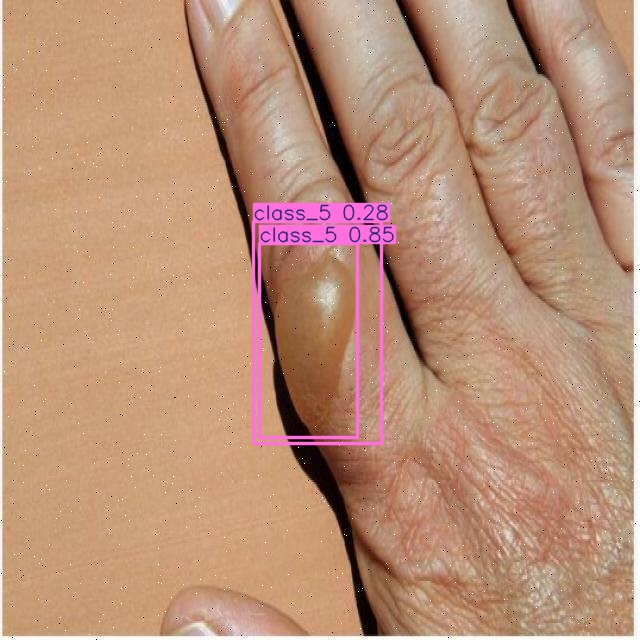

Displayed: /content/runs/detect/predict/1er_jpg.rf.2bada2b774cd91d57c9edb1df36b75e8.jpg



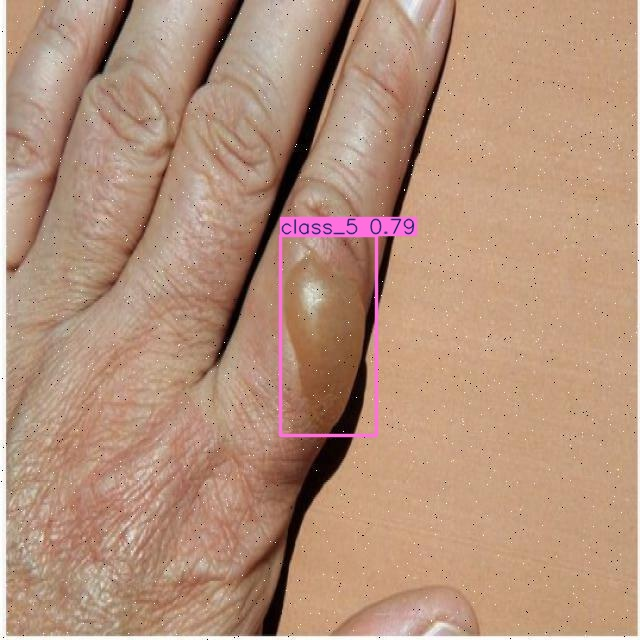

Displayed: /content/runs/detect/predict/1er_jpg.rf.3b6ad01c3d73cccedf8b0ec3c2453ea5.jpg



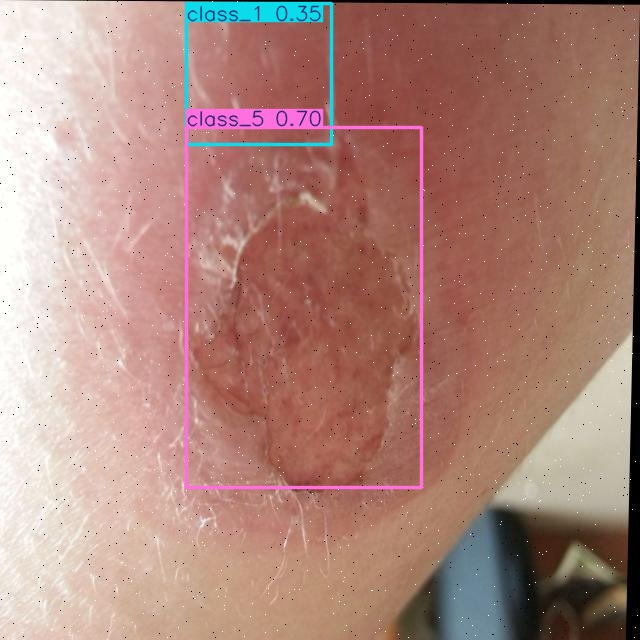

Displayed: /content/runs/detect/predict/20130803-094920-11-56a2f5665f9b58b7d0cfdf4d_jpg.rf.0e59c657cd865af5cc7c1f6cdfd92810.jpg



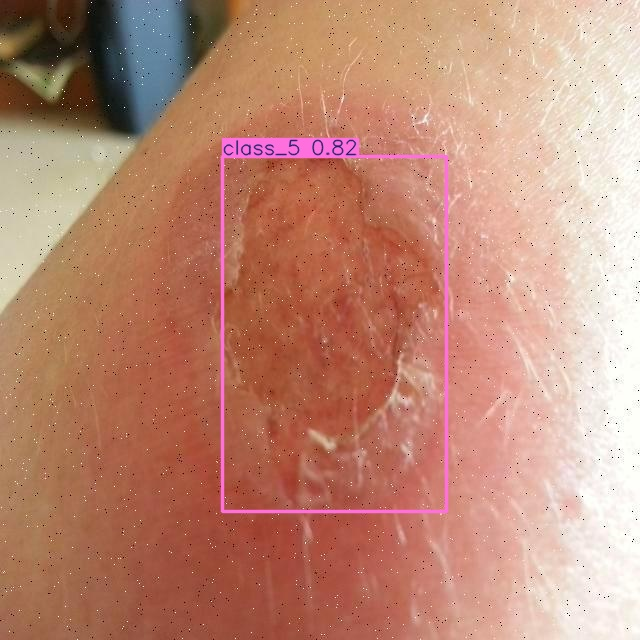

Displayed: /content/runs/detect/predict/20130803-094920-11-56a2f5665f9b58b7d0cfdf4d_jpg.rf.6d19a59c520c17e7656c73ef7cfa33b0.jpg



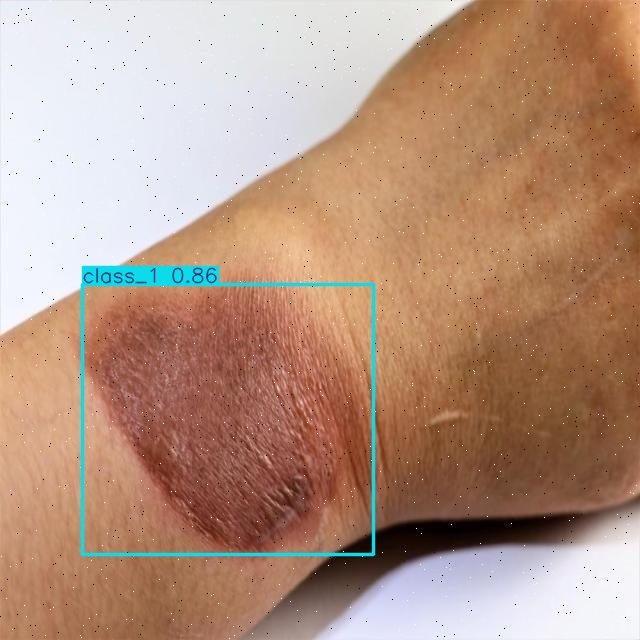

Displayed: /content/runs/detect/predict/2449911_jpg.rf.1192059c2f90c7aa3afabadc9396598b.jpg



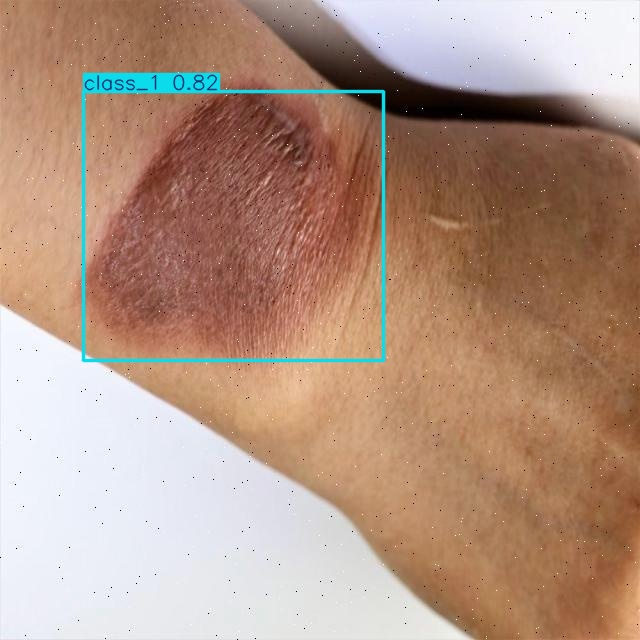

Displayed: /content/runs/detect/predict/2449911_jpg.rf.5bf346884ca5e21c6c96085e49fd1f38.jpg



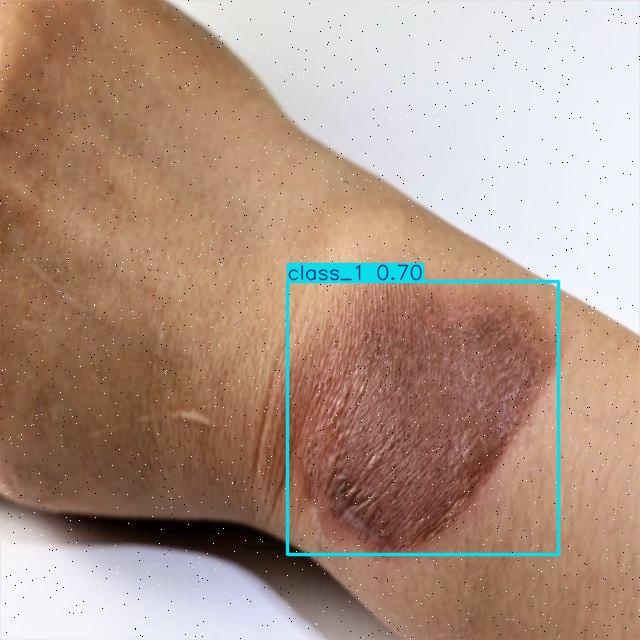

Displayed: /content/runs/detect/predict/2449911_jpg.rf.8f3dd03746f98dbe870ffa5b722367e8.jpg



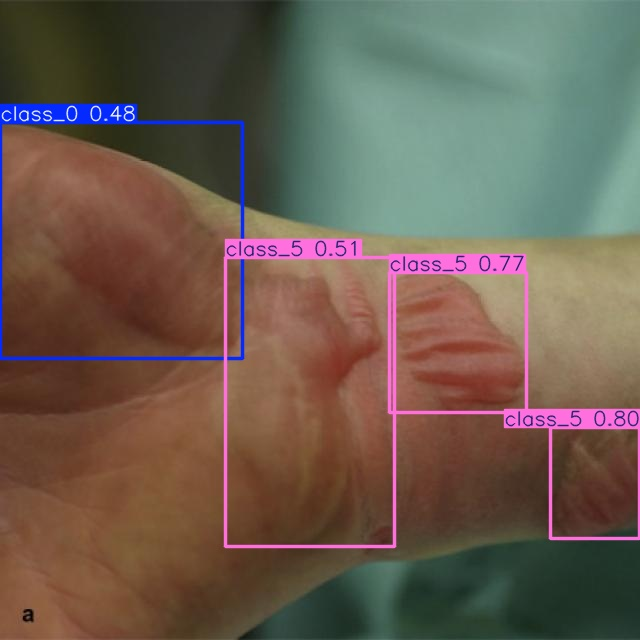

Displayed: /content/runs/detect/predict/2_jpg.rf.233f44fe1bd4b0629a8405b0a513afba.jpg



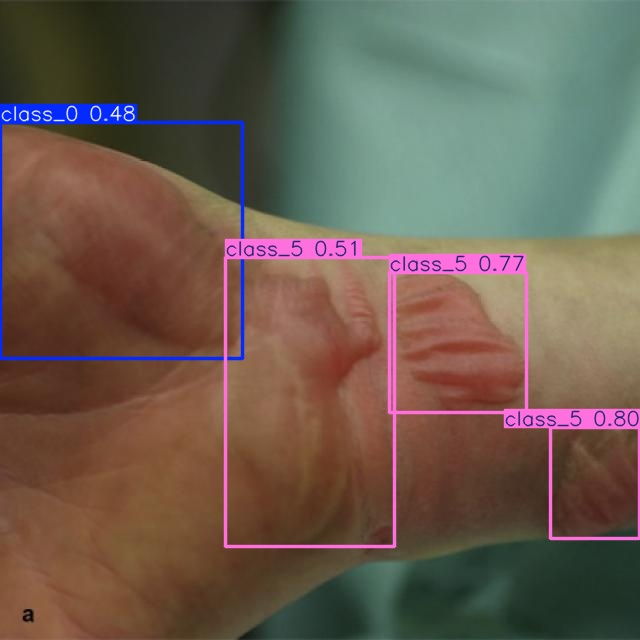

Displayed: /content/runs/detect/predict/2_jpg.rf.2a5f69259b6bf506c7237f80f1ac92d5.jpg



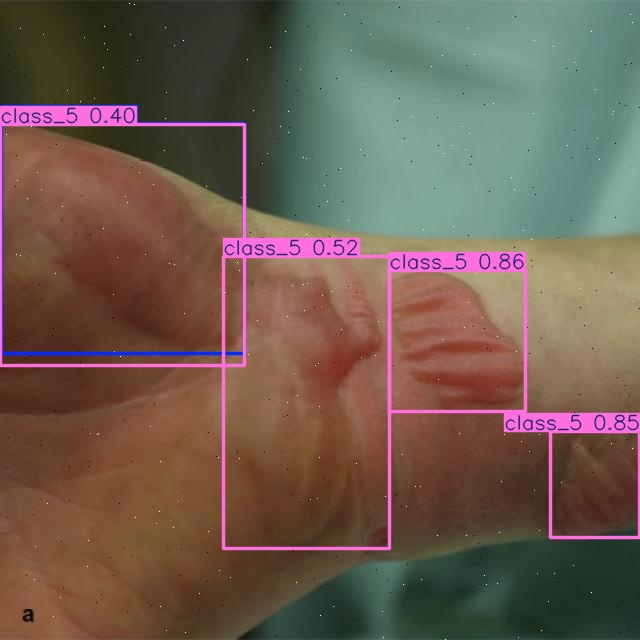

Displayed: /content/runs/detect/predict/2_jpg.rf.4e4575dc7101f15c223193f5c1a8cd61.jpg



In [ ]:

import glob
from IPython.display import Image, display


prediction_path = '/content/runs/detect/predict/'

# Get the first 10 .jpg images and display them
for image_path in sorted(glob.glob(f'{prediction_path}*.jpg'))[:10]:
    display(Image(filename=image_path, height=400))
    print(f"Displayed: {image_path}\n")


In [ ]:

!zip -r runs.zip /content/runs


from google.colab import files
files.download('runs.zip')


  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train2/ (stored 0%)
  adding: content/runs/detect/train2/BoxF1_curve.png (deflated 7%)
  adding: content/runs/detect/train2/val_batch1_pred.jpg (deflated 8%)
  adding: content/runs/detect/train2/val_batch2_pred.jpg (deflated 9%)
  adding: content/runs/detect/train2/val_batch2_labels.jpg (deflated 9%)
  adding: content/runs/detect/train2/BoxP_curve.png (deflated 5%)
  adding: content/runs/detect/train2/results.png (deflated 7%)
  adding: content/runs/detect/train2/train_batch1.jpg (deflated 7%)
  adding: content/runs/detect/train2/train_batch3851.jpg (deflated 10%)
  adding: content/runs/detect/train2/confusion_matrix.png (deflated 24%)
  adding: content/runs/detect/train2/val_batch0_pred.jpg (deflated 7%)
  adding: content/runs/detect/train2/labels.jpg (deflated 23%)
  adding: content/runs/detect/train2/val_batch1_labels.jpg (deflated 8%)
  adding: content/runs/detect/train2/val

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>